<a href="https://colab.research.google.com/github/luladc/IA2/blob/main/LAB1_IA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificador Binario Perros vs Gatos**

**Introducción y Configuración del Entorno**

Importamos las librerías necesarias de PyTorch, Torchvision y herramientas matemáticas. Además, configuramos el dispositivo de ejecución para utilizar aceleración por hardware (GPU/CUDA) si está disponible, lo cual reducirá drásticamente los tiempos de entrenamiento.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import random


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo a utilizar: {device}")

Dispositivo a utilizar: cuda


**Descarga y Preparación del Dataset**

Conectamos el entorno con Google Drive para acceder a las credenciales de Kaggle y descargamos automáticamente el dataset "Dog and Cat Classification". Luego, descomprimimos los archivos en un directorio local para facilitar su lectura durante el entrenamiento.
Cats and Dogs Classification Dataset https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset  ese es el enlace al dataset

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

!mkdir -p ~/.kaggle

!cp /content/drive/MyDrive/DATASETS/kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

!unzip -q dog-and-cat-classification-dataset.zip -d ./PetImages

print("¡Dataset descargado y listo para usar!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:05<00:00, 152MB/s]

¡Dataset descargado y listo para usar!


**Transformaciones, Carga y División de Datos**

Definimos las transformaciones para redimensionar todas las imágenes al tamaño exigido (256x256 píxeles), convertirlas a tensores y normalizar sus valores. Cargamos el dataset utilizando ImageFolder y lo dividimos en tres subconjuntos usando proporciones estándar: Entrenamiento (70%), Validación (15%) y Prueba (15%). Finalmente, encapsulamos los datos en DataLoaders para procesarlos en lotes (batches).

In [ ]:
import torch
import torchvision
from torchvision import transforms
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from PIL import ImageFile

# Parche para imágenes truncadas/corruptas
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Transformación a 200x200 y Normalización
transformaciones = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 2. Carga del dataset
dataset_completo = torchvision.datasets.ImageFolder(root='./PetImages/PetImages', transform=transformaciones)

# 3. División en Train (70%), Validation (15%) y Test (15%)
total_size = len(dataset_completo)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset_completo, [train_size, val_size, test_size]
)

# 4. Creación del diccionario de DataLoaders
dataloader = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True),
    'val': torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False),
    'test': torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
}

print(f"Total imágenes: {total_size}")
print(f"Entrenamiento: {train_size} | Validación: {val_size} | Prueba: {test_size}")

Total imágenes: 24998
Entrenamiento: 17498 | Validación: 3749 | Prueba: 3751


**Limpieza y Verificación de Integridad**

Los datasets de imágenes masivos suelen contener archivos truncados o corruptos que pueden interrumpir el entrenamiento. En esta celda iteramos sobre el directorio de imágenes utilizando la librería PIL para verificar la integridad estructural de cada archivo y alertar sobre aquellos que deban ser descartados.

In [1]:
from PIL import Image
import os

ruta_dataset = "ruta/a/tu/carpeta/de/imagenes"

for raiz, carpetas, archivos in os.walk(ruta_dataset):
    for archivo in archivos:
        try:
            ruta_img = os.path.join(raiz, archivo)
            img = Image.open(ruta_img)
            img.verify() # Verifica que el archivo esté íntegro
        except (IOError, SyntaxError) as e:
            print(f"Imagen corrupta encontrada y lista para borrar: {ruta_img}")
            os.remove(ruta_img)

**Definición del Modelo Neuronal MLP y Funciones de Entrenamiento**

Construimos un modelo Perceptrón Multicapa (MLP) utilizando nn.Sequential. La red aplana las imágenes de 256x256x3 dimensiones y las pasa por capas lineales ocultas. Aplicamos buenas prácticas de regularización incluyendo BatchNorm1d y Dropout(0.5) para evitar el sobreajuste, utilizando ReLU como función de activación. También definimos la función fit, la cual orquesta el bucle de entrenamiento, evalúa la función de pérdida (CrossEntropyLoss), guarda los mejores pesos del modelo e implementa Early Stopping para detener el proceso si la precisión no mejora.

In [ ]:
def build_model(D_in=256*256*3, H1=512, H2=128, D_out=2):
    return torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(D_in, H1),
        torch.nn.BatchNorm1d(H1),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.5),
        torch.nn.Linear(H1, H2),
        torch.nn.BatchNorm1d(H2),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.5),
        torch.nn.Linear(H2, D_out)
    ).to(device)

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def fit(model, dataloader, optimizer, scheduler=None, epochs=10, log_each=1, early_stopping=0, verbose=1):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            x_b, y_b = x_b.to(device), y_b.to(device)
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b, y_b = x_b.to(device), y_b.to(device)
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
        step += 1

        if scheduler:
            scheduler.step()

        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar")
            break
        if not e % log_each and verbose:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.6f}")

    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

**Ejecución del Entrenamiento y Optimización**

Instanciamos el modelo y definimos los criterios de optimización: el optimizador Adam con una tasa de aprendizaje inicial de 0.001, y un planificador StepLR que reducirá la tasa de aprendizaje a la mitad cada 5 épocas. Ejecutamos el entrenamiento por un máximo de 20 épocas.

In [ ]:
modelo = build_model()

optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(optimizador, step_size=5, gamma=0.5)

historial = fit(modelo, dataloader, optimizador, scheduler, epochs=20, early_stopping=10, verbose=1)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/20 loss 0.68324 acc 0.58323 val_loss 0.64627 val_acc 0.62276 lr 0.001000


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 2/20 loss 0.65101 acc 0.61996 val_loss 0.63721 val_acc 0.63254 lr 0.001000


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch 18/20 loss 0.44301 acc 0.79221 val_loss 0.63466 val_acc 0.66225 lr 0.000125


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 19/20 loss 0.42803 acc 0.79843 val_loss 0.63866 val_acc 0.66798 lr 0.000125


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 20/20 loss 0.41688 acc 0.80712 val_loss 0.64123 val_acc 0.67473 lr 0.000125


**Cálculo de Métricas de Clasificación y Curva ROC**

Pasamos el conjunto de validación por el modelo entrenado (sin calcular gradientes) para obtener las predicciones. Extraemos y mostramos métricas clave de desempeño binario: la Matriz de Confusión, la Precisión, la Sensibilidad (Recall) y el F1-Score. Posteriormente, calculamos y graficamos la Curva ROC junto con el área bajo la curva (AUC) para evaluar la capacidad de separación de clases del modelo.

Matriz de Confusión:
[[1315  540]
 [ 658 1236]]

Precision: 0.6959
Recall: 0.6526
F1-Score: 0.6736


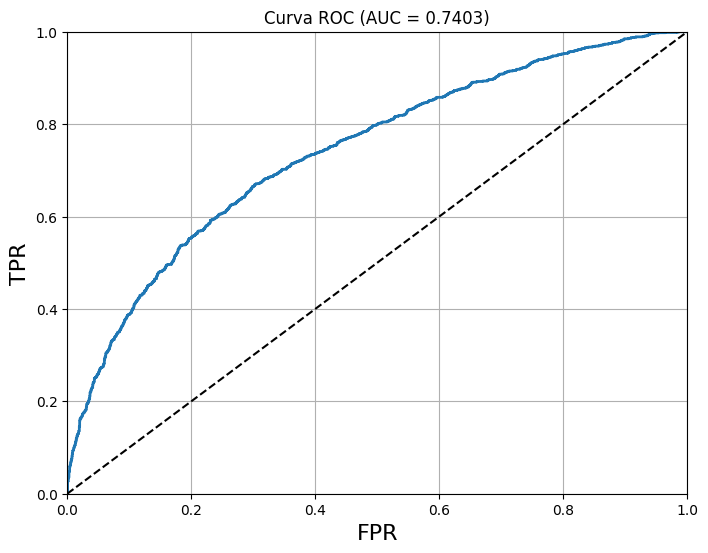

In [ ]:
y_true_list = []
y_pred_list = []
y_proba_list = []

modelo.eval()
with torch.no_grad():
    for x_b, y_b in dataloader['val']:
        x_b = x_b.cuda()
        y_pred = modelo(x_b)

        # Obtenemos las clases predichas y las probabilidades para la clase positiva (Perro = 1)
        y_probas = softmax(y_pred)
        y_pred_class = torch.argmax(y_probas, axis=1)

        y_true_list.extend(y_b.cpu().numpy())
        y_pred_list.extend(y_pred_class.cpu().numpy())
        y_proba_list.extend(y_probas[:, 1].cpu().numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_proba = np.array(y_proba_list)

# 1. Matriz de Confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_true, y_pred))

# 2. Métricas de Clasificación
p = precision_score(y_true, y_pred)
r = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\nPrecision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")

# 3. Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
auc = roc_auc_score(y_true, y_proba)

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('FPR', fontsize=16)
    plt.ylabel('TPR', fontsize=16)
    plt.grid(True)
    plt.title(f"Curva ROC (AUC = {auc:.4f})")

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

**Prueba de Inferencia Individual**

Seleccionamos una imagen aleatoria del dataset de validación para realizar una prueba práctica. Preparamos el tensor, lo pasamos por el modelo y utilizamos una capa Softmax para determinar la probabilidad de pertenencia a cada clase. Finalmente, visualizamos la imagen original junto con el veredicto del modelo y su nivel de confianza porcentual.

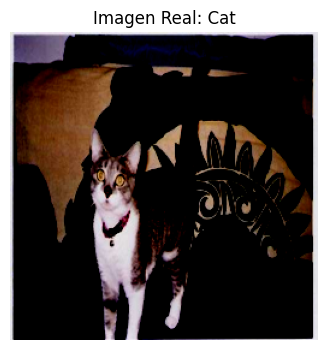

------------------------------
VEREDICTO DEL MODELO:
Predicción: ¡Es un Cat!
Confianza: 62.58%
------------------------------
✅ ¡El modelo acertó!


In [ ]:
import matplotlib.pyplot as plt
import random

# Aseguramos que el modelo esté en modo evaluación
modelo.eval()

# 1. Elegimos un índice al azar del conjunto de validación
indice = random.randint(0, len(val_dataset) - 1)
imagen_tensor, etiqueta_real = val_dataset[indice]

# Extraemos el nombre de las clases ('Cat' y 'Dog') generadas por ImageFolder
clases = dataset_completo.classes

# 2. Preparamos la imagen para visualizarla con Matplotlib
# PyTorch usa el formato [Canales, Alto, Ancho], pero Matplotlib requiere [Alto, Ancho, Canales]
imagen_mostrar = imagen_tensor.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(4, 4))
plt.imshow(imagen_mostrar)
plt.axis('off')
plt.title(f"Imagen Real: {clases[etiqueta_real]}")
plt.show()

# 3. Preparamos el tensor para el modelo
# El modelo espera lotes (batches), así que añadimos una dimensión extra al inicio: [1, 3, 200, 200]
imagen_entrada = imagen_tensor.unsqueeze(0).to(device)

# 4. Hacemos la predicción
with torch.no_grad():
    prediccion_bruta = modelo(imagen_entrada)

    # Aplicamos Softmax para convertir la salida en probabilidades
    probabilidades = softmax(prediccion_bruta)

    # Obtenemos el índice de la probabilidad más alta
    clase_predicha = torch.argmax(probabilidades, axis=1).item()

    # Porcentaje de confianza de la predicción
    confianza = probabilidades[0][clase_predicha].item() * 100

# 5. Imprimimos el veredicto final
print("-" * 30)
print(f"VEREDICTO DEL MODELO:")
print(f"Predicción: ¡Es un {clases[clase_predicha]}!")
print(f"Confianza: {confianza:.2f}%")
print("-" * 30)

if clase_predicha == etiqueta_real:
    print("✅ ¡El modelo acertó!")
else:
    print("❌ El modelo se equivocó.")

**Visualización Integral del Rendimiento**

Generamos un panel de control gráfico (dashboard) utilizando Matplotlib y Seaborn para resumir el entrenamiento. Este panel contrasta la evolución de la pérdida entre entrenamiento y validación, muestra un mapa de calor para la matriz de confusión, grafica las métricas de clasificación en un diagrama de barras y consolida la curva ROC, ofreciendo un reporte detallado del desempeño general.

Accuracy Global: 0.6804


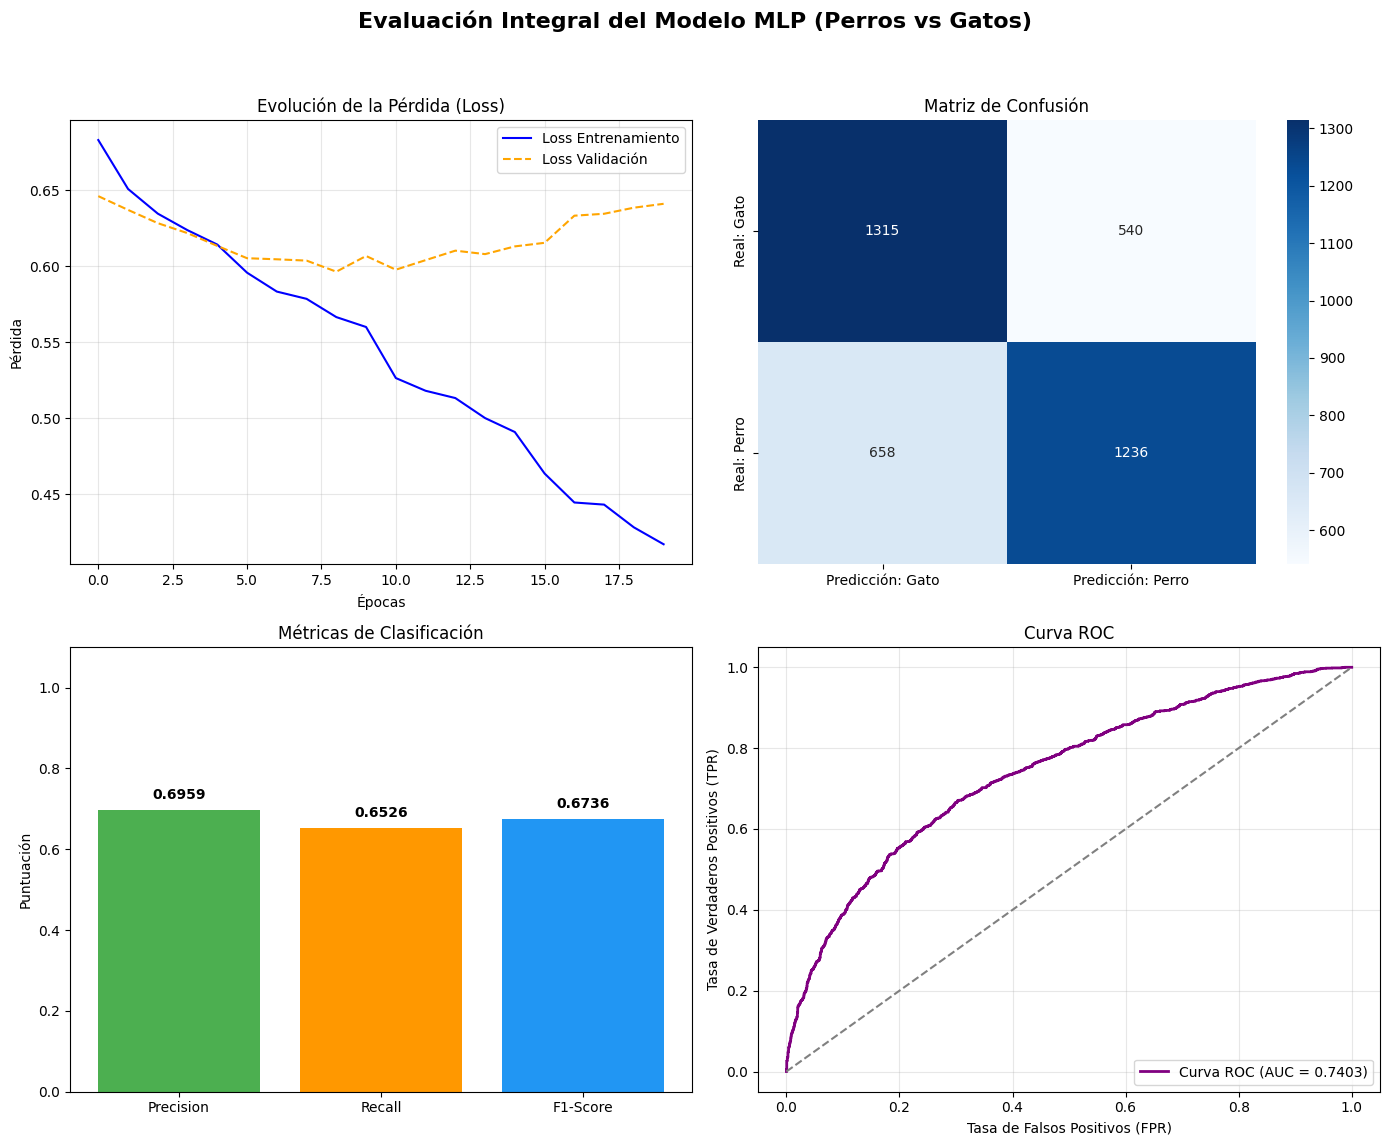

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

modelo.eval()
y_true, y_pred, y_proba = [], [], []

with torch.no_grad():
    for x_b, y_b in dataloader['val']:
        x_b = x_b.to(device)
        pred_bruta = modelo(x_b)
        probas = softmax(pred_bruta)

        y_true.extend(y_b.numpy())
        y_pred.extend(torch.argmax(probas, axis=1).cpu().numpy())
        y_proba.extend(probas[:, 1].cpu().numpy()) # Probabilidad clase 1 (Dog)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

acc = accuracy_score(y_true, y_pred)
p = precision_score(y_true, y_pred)
r = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_proba)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy Global: {acc:.4f}")

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Evaluación Integral del Modelo MLP (Perros vs Gatos)', fontsize=16, fontweight='bold')

axs[0, 0].plot(historial['loss'], label='Loss Entrenamiento', color='blue')
axs[0, 0].plot(historial['val_loss'], label='Loss Validación', color='orange', linestyle='--')
axs[0, 0].set_title('Evolución de la Pérdida (Loss)')
axs[0, 0].set_xlabel('Épocas')
axs[0, 0].set_ylabel('Pérdida')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[0, 1],
            xticklabels=['Predicción: Gato', 'Predicción: Perro'],
            yticklabels=['Real: Gato', 'Real: Perro'])
axs[0, 1].set_title('Matriz de Confusión')

metricas_nombres = ['Precision', 'Recall', 'F1-Score']
metricas_valores = [p, r, f1]
colores = ['#4CAF50', '#FF9800', '#2196F3']

barras = axs[1, 0].bar(metricas_nombres, metricas_valores, color=colores)
axs[1, 0].set_ylim(0, 1.1)
axs[1, 0].set_title('Métricas de Clasificación')
axs[1, 0].set_ylabel('Puntuación')

for barra in barras:
    yval = barra.get_height()
    axs[1, 0].text(barra.get_x() + barra.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

fpr, tpr, thresholds = roc_curve(y_true, y_proba)
axs[1, 1].plot(fpr, tpr, color='purple', lw=2, label=f'Curva ROC (AUC = {auc:.4f})')
axs[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axs[1, 1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axs[1, 1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axs[1, 1].set_title('Curva ROC')
axs[1, 1].legend(loc="lower right")
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()